In [8]:
%load_ext autoreload
%autoreload 2

import pickle

import pandas as pd
import ultraplot as uplt

import utils.sif_processing as sif

In [175]:
region = 'Allegheny_Reservoir_2021'

In [176]:
with open(f'../Data/SIF/SingleObs_Poly_TROPOMISIF743daily_743ErrorSmaller10_SIFin-2to5_{region}_US_2019_2025_WTOA_new.pkl', 'rb') as f:
    data = pickle.load(f)

In [177]:
sif_df = data[['SIF_743', 'SIF_ERROR_743', 'Mean_TOA_RAD_743','Day', 'Month', 'Year']].copy()
sif_df['SIF_743_TOAnorm'] = sif_df['SIF_743'] / sif_df['Mean_TOA_RAD_743']
sif_df['date'] = pd.to_datetime(sif_df[['Year', 'Month', 'Day']])
sif_df = sif_df.set_index('date')

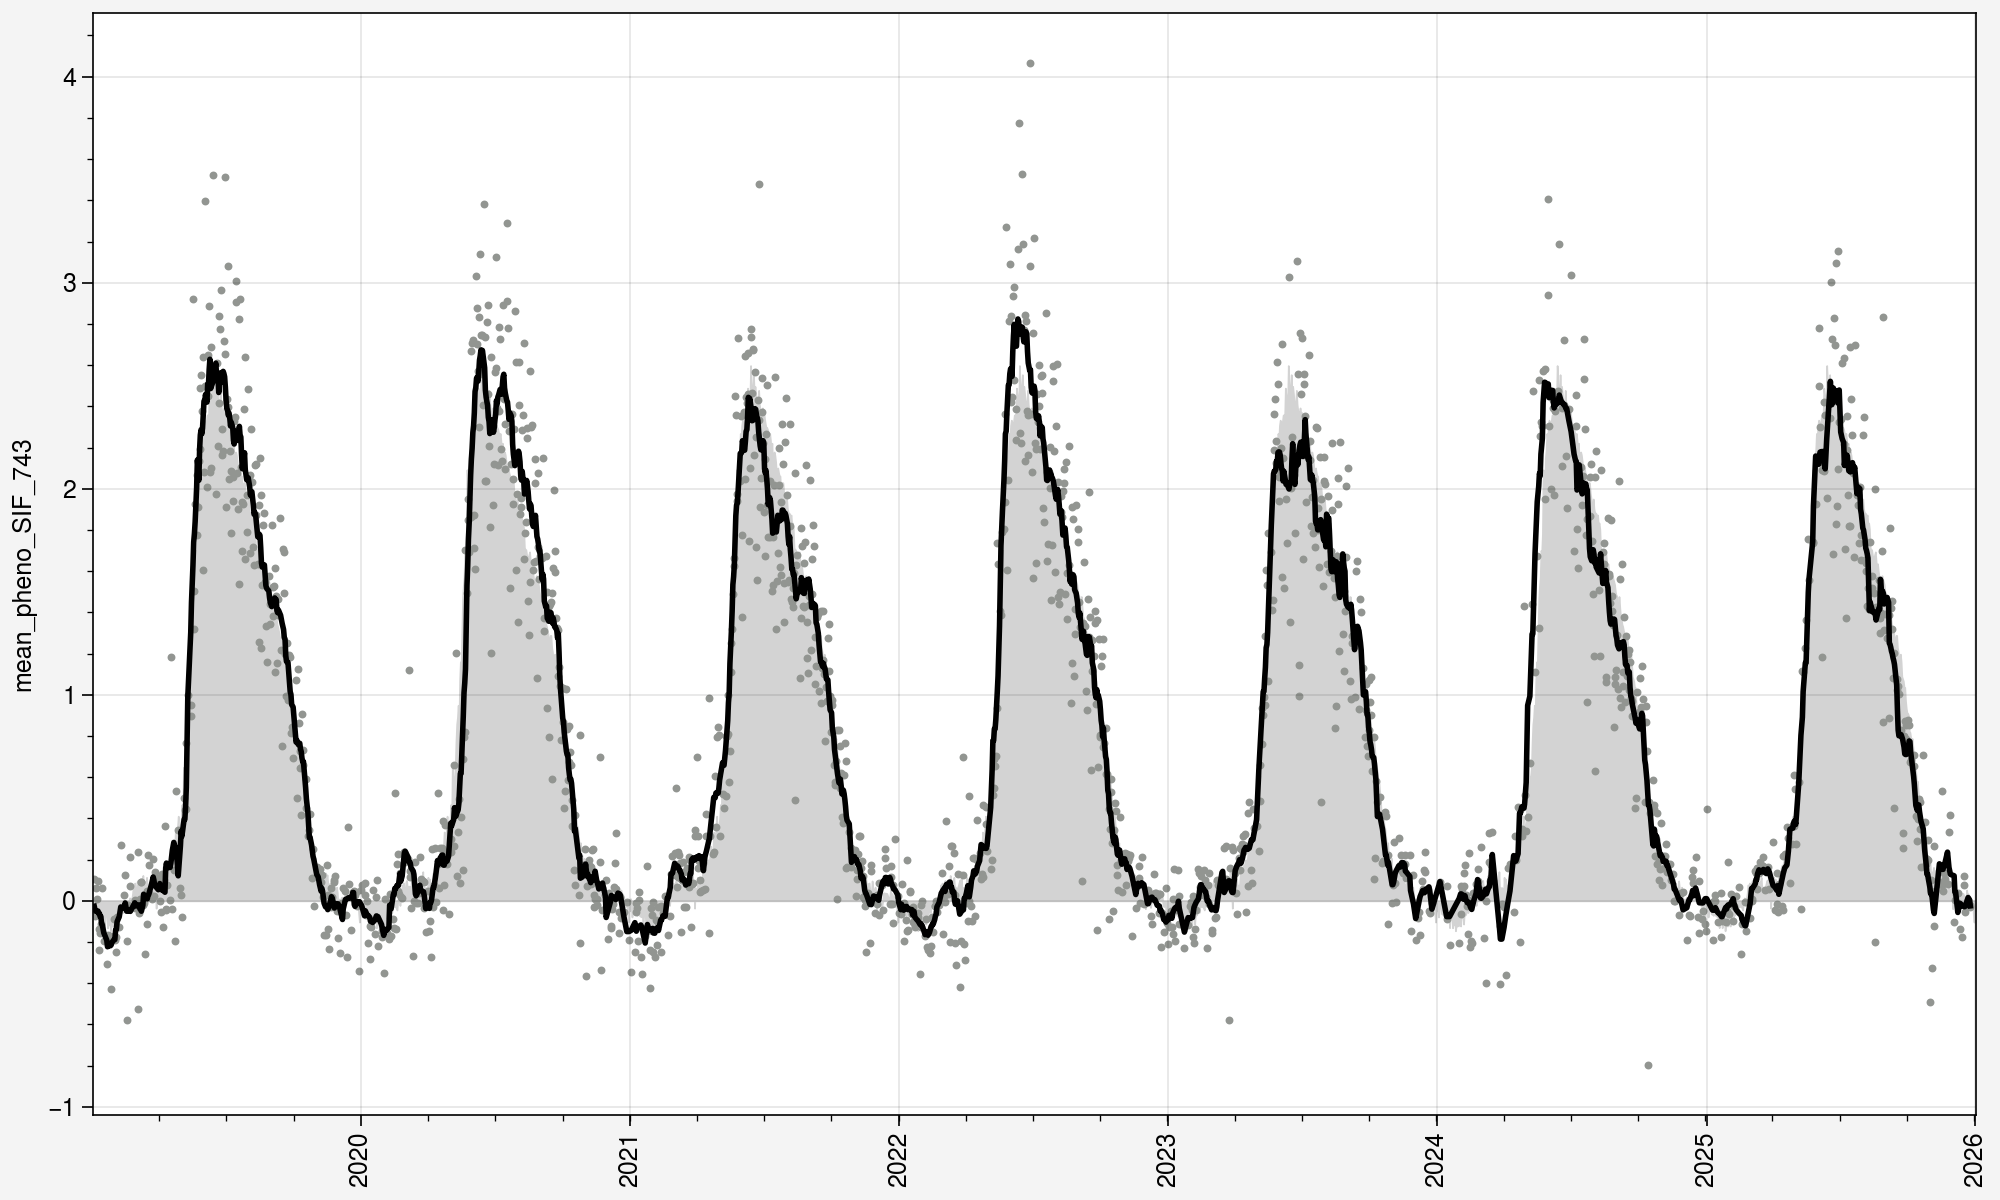

In [178]:
fig, ax = uplt.subplots(figsize=(10,6))

analysis_sif = sif.create_sif_analysis_df(sif_df, ['SIF_743'], 2019, 2025, 14)

ax.fill_between(analysis_sif.index, analysis_sif['mean_pheno_SIF_743'], 
                label='Mean Phenology', color='lightgray')
# Need to interpolate missing values for days with no SIF observations.
rm_sif = analysis_sif['running_mean_SIF_743'].dropna()
ax.plot(rm_sif.index, rm_sif, 
        color='black', lw=2, label=f'Running Mean (14-day)')
ax.scatter(analysis_sif.index, analysis_sif['daily_mean_SIF_743'],
           color='gray', ms=5, label=f'SIF 743')

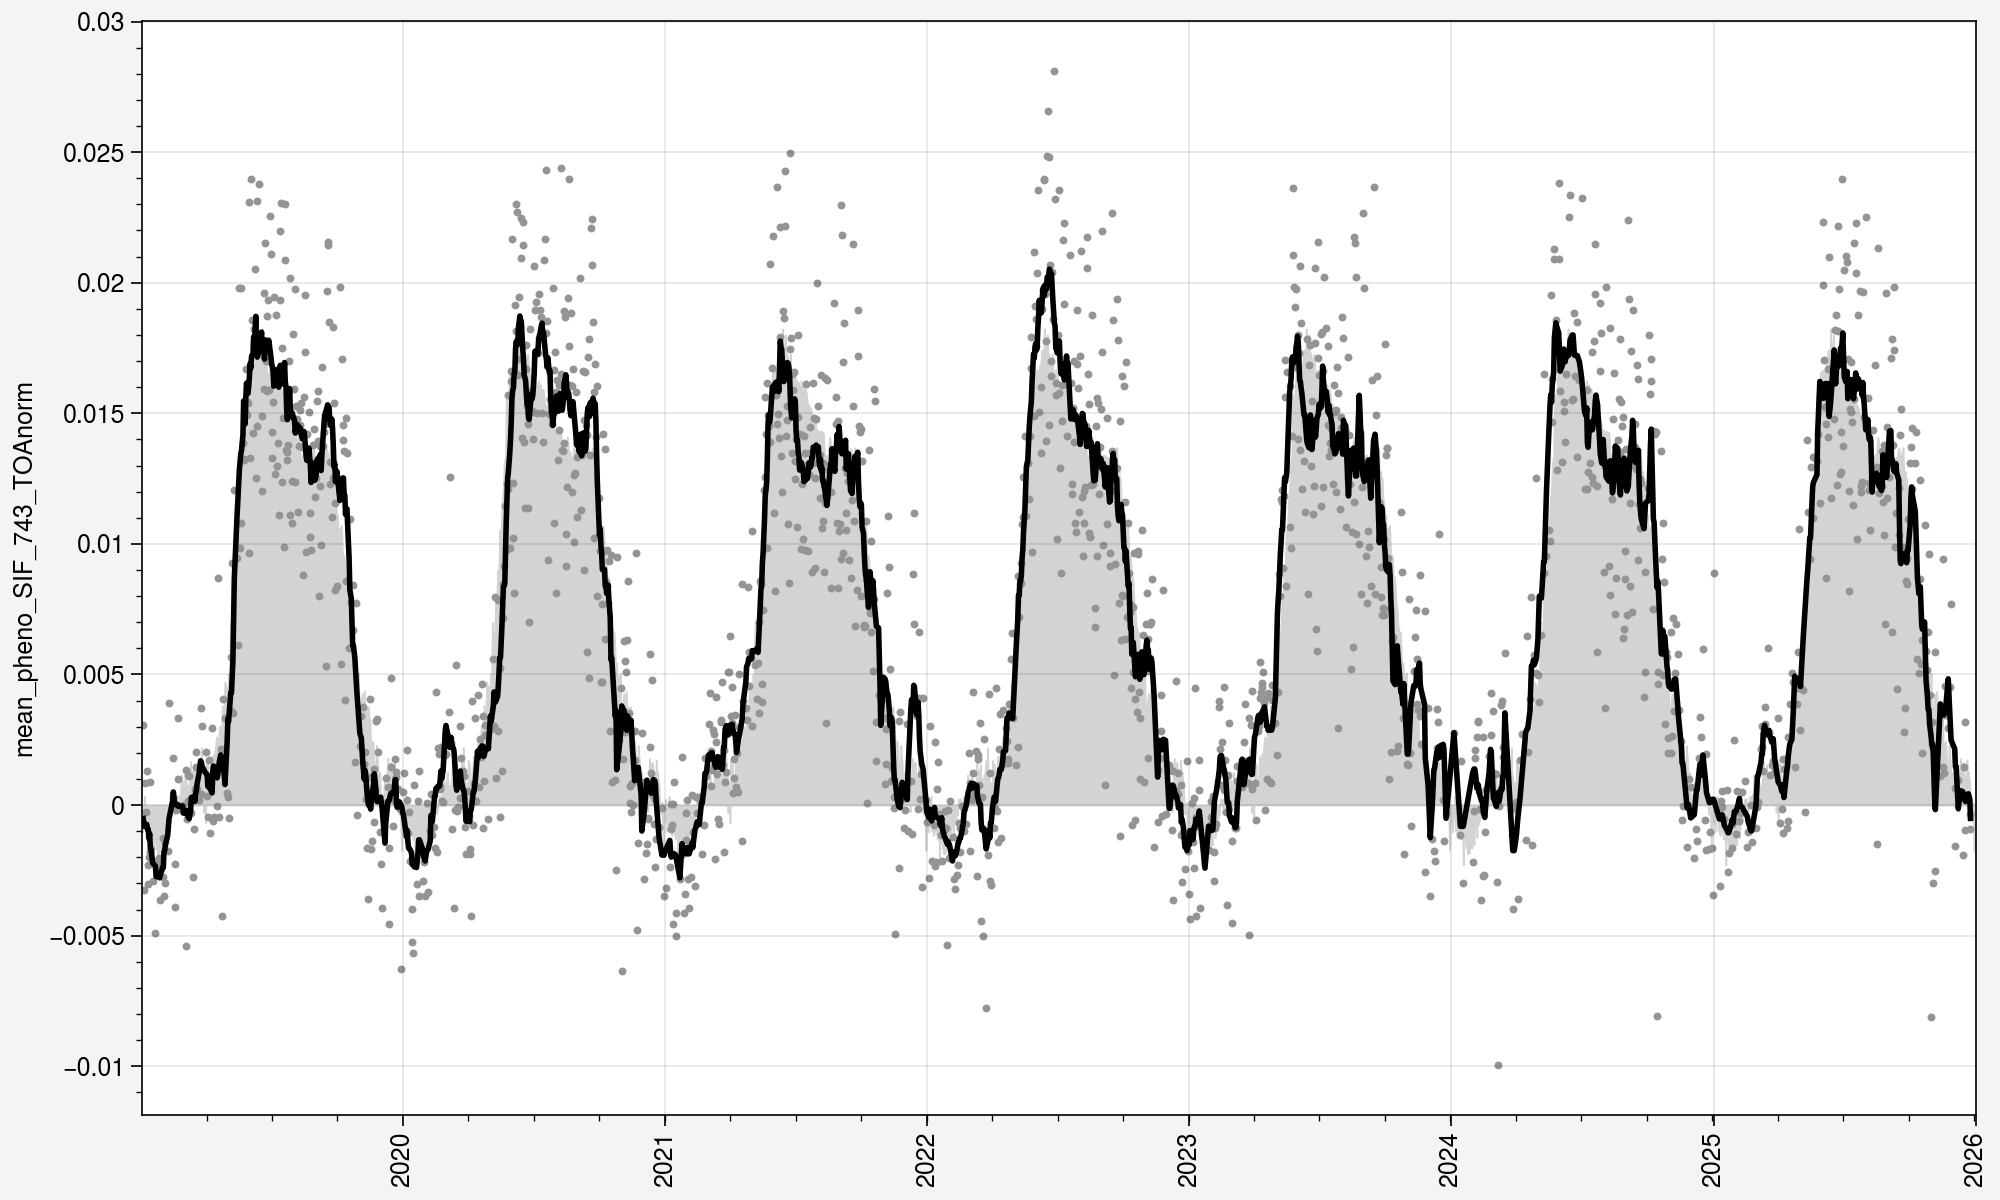

In [179]:
fig, ax = uplt.subplots(figsize=(10,6))

analysis_sif = sif.create_sif_analysis_df(sif_df, ['SIF_743_TOAnorm'], 2019, 2025, 14)

ax.fill_between(analysis_sif.index, analysis_sif['mean_pheno_SIF_743_TOAnorm'], 
                label='Mean Phenology', color='lightgray')
# Need to interpolate missing values for days with no SIF observations.
rm_sif = analysis_sif['running_mean_SIF_743_TOAnorm'].dropna()
ax.plot(rm_sif.index, rm_sif, 
        color='black', lw=2, label=f'Running Mean (14-day)')
ax.scatter(analysis_sif.index, analysis_sif['daily_mean_SIF_743_TOAnorm'],
           color='gray', ms=5, label=f'SIF 743')

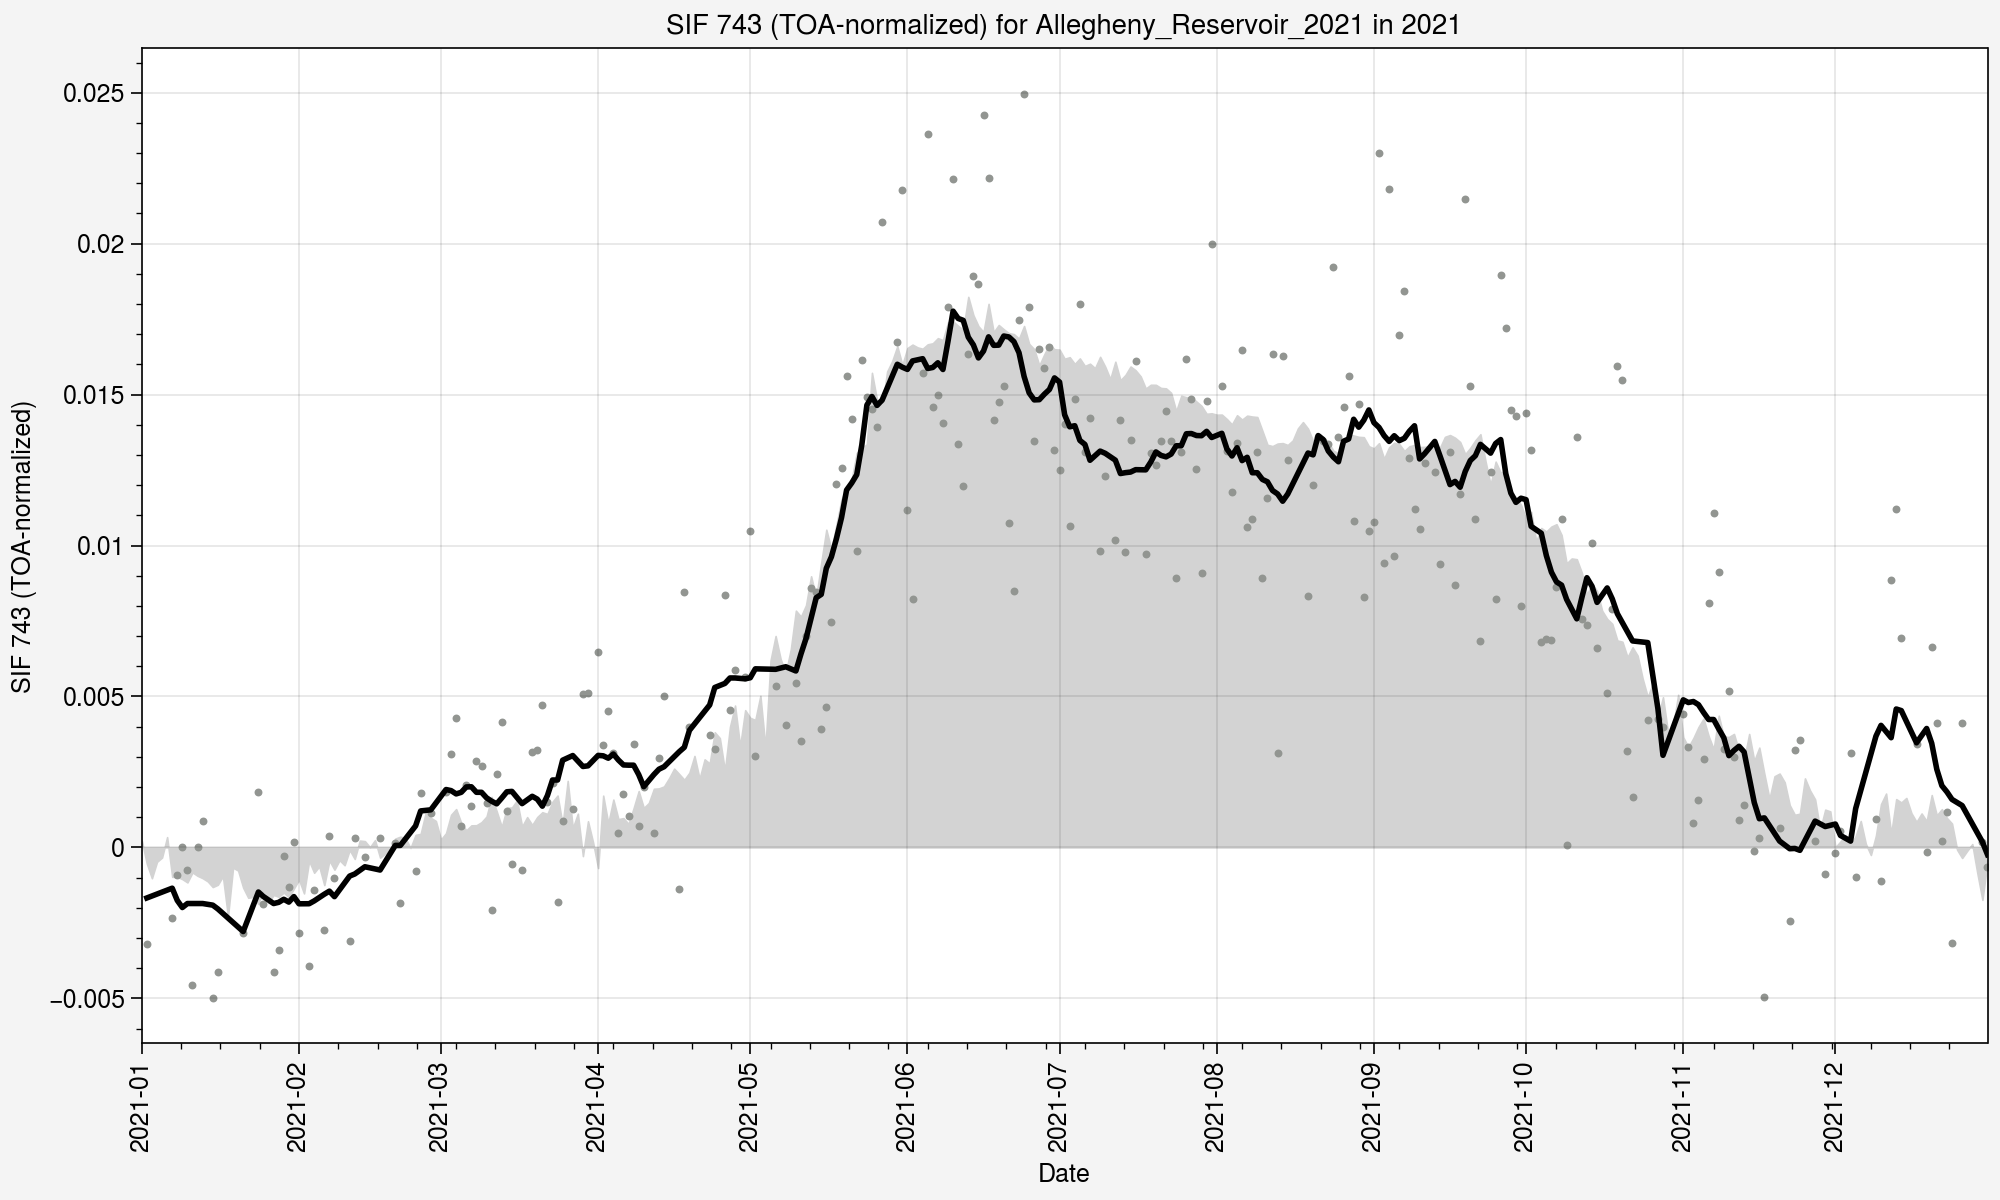

In [181]:
fig, ax = uplt.subplots(figsize=(10,6))

analysis_sif = sif.create_sif_analysis_df(sif_df, ['SIF_743_TOAnorm'], 2019, 2025, 14)
analysis_sif = analysis_sif[analysis_sif.index.year == 2021]
ax.fill_between(analysis_sif.index, analysis_sif['mean_pheno_SIF_743_TOAnorm'], 
                label='Mean Phenology', color='lightgray')
# Need to interpolate missing values for days with no SIF observations.
rm_sif = analysis_sif['running_mean_SIF_743_TOAnorm'].dropna()
ax.plot(rm_sif.index, rm_sif, 
        color='black', lw=2, label=f'Running Mean (14-day)')
ax.scatter(analysis_sif.index, analysis_sif['daily_mean_SIF_743_TOAnorm'],
           color='gray', ms=5, label=f'SIF 743')

ax.format(ylabel='SIF 743 (TOA-normalized)', xlabel='Date', title=f'SIF 743 (TOA-normalized) for {region} in 2021')